# Member 2 — XGBoost & Decision Tree
**COM3032/COMM074 · Airline Route Profitability · CRISP-DM: Modelling & Evaluation**

**Student:** Member 2
**Primary Model:** XGBoost Classifier
**Member 2 – Decision Tree:** Tuned with entropy criterion, no class balancing, deeper growth (max 11)
**Data:** Unscaled for both models — gradient boosted trees and decision trees are scale-invariant

---

### Metric Justification

| Metric | Business Meaning |
|--------|------------------|
| F1-Score | Primary metric — balances precision and recall for imbalanced classification. |
| ROC-AUC | Ranking ability across all thresholds — used for cross-member comparison. |
| MCC | Accounts for all four confusion matrix cells. Above 0.4 = genuine discriminative ability. |
| TPR (Recall) | Fraction of profitable routes correctly identified. |
| TNR | Fraction of loss-making routes correctly flagged. |
| FPR | Fraction of loss-making routes wrongly approved. Drives financial cost. |
| Overfit Gap | Train F1 minus Test F1. < 0.05 = good fit; 0.05–0.10 = borderline; > 0.10 = memorising. |

## Section 1 — Imports and Setup

XGBoost requires the `xgboost` package. All paths point to the shared `processed_data/` folder.

In [20]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import (RandomizedSearchCV, GridSearchCV,
                                     StratifiedKFold, cross_val_score, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              matthews_corrcoef)

print('Libraries loaded.')

Libraries loaded.


## Section 2 — Load Data

XGBoost uses unscaled data — gradient boosted trees use threshold comparisons and are not affected by feature scale. Decision Tree also uses unscaled data.

In [21]:
from pathlib import Path

RANDOM_STATE = 42
MEMBER       = 'member2'
# FP_COST: estimated quarterly operating cost of maintaining one unprofitable route
# FN_COST: estimated foregone revenue from incorrectly retiring a profitable route
FP_COST      = 42000
FN_COST      = 30000

MEMBER_DIR = Path.cwd()
BASE       = MEMBER_DIR.parent
PROC       = BASE / "processed_data"
FIG_DIR    = MEMBER_DIR
MEMBER_DIR.mkdir(parents=True, exist_ok=True)

print("Member dir:", MEMBER_DIR)
print("Base folder:", BASE)
print("Processed folder:", PROC)
print("Processed folder exists:", PROC.exists())

X_train = pd.read_csv(PROC / "X_train.csv")
X_val   = pd.read_csv(PROC / "X_val.csv")
X_test  = pd.read_csv(PROC / "X_test.csv")

y_train = pd.read_csv(PROC / "y_train.csv").squeeze()
y_val   = pd.read_csv(PROC / "y_val.csv").squeeze()
y_test  = pd.read_csv(PROC / "y_test.csv").squeeze()

with open(PROC / "feature_names.json") as f:
    feature_names = json.load(f)

C_PROFIT  = '#2DC653'
C_LOSS    = '#E84855'
C_NEUTRAL = '#2E86AB'

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Class balance — Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Member dir: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\Member 2
Base folder: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project
Processed folder: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\processed_data
Processed folder exists: True
Train: (11997, 37), Val: (1500, 37), Test: (1500, 37)
Class balance — Train: 0.637, Val: 0.637, Test: 0.637


## Section 3 — Utility Functions

Identical utility function suite across all five members for consistent evaluation.

In [22]:

def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1_Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

def evaluate_enhanced(name, model, X_tr, y_tr, X_te, y_te):
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1]
    y_pred_tr = model.predict(X_tr)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    mcc  = matthews_corrcoef(y_te, y_pred)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    f1_train = f1_score(y_tr, y_pred_tr, zero_division=0)
    gap = round(f1_train - f1, 4)
    gap_label = ('underfitting' if gap < 0 else
                 'good fit'     if gap < 0.05 else
                 'borderline'   if gap < 0.10 else
                 'memorising')

    fp_cost = fp * FP_COST

    print(f'=== Enhanced Evaluation: {name} ===')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (FP count: {fp}, FP cost: £{fp_cost:,})')
    print(f'  Recall    : {rec:.4f}  (FN count: {fn})')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  MCC       : {mcc:.4f}  ({"genuine discriminative ability" if mcc > 0.4 else "limited signal"})')
    print(f'  TNR       : {tnr:.4f}')
    print(f'  FPR       : {fpr:.4f}')
    print(f'  Train F1  : {f1_train:.4f}')
    print(f'  Test  F1  : {f1:.4f}')
    print(f'  Overfit Gap: {gap:.4f}  [{gap_label}]')

    return {
        'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4),
        'MCC': round(mcc, 4), 'TNR': round(tnr, 4), 'FPR': round(fpr, 4),
        'FP_Cost_GBP': fp_cost, 'Train_F1': round(f1_train, 4), 'Overfit_Gap': gap,
        'Overfit_Label': gap_label
    }

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loss-Making', 'Profitable'],
                yticklabels=['Loss-Making', 'Profitable'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

def plot_roc(y_true, y_prob, label, ax, color='#2E86AB'):
    fpr_v, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr_v, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC Curve', fontweight='bold')
    ax.legend()

def plot_learning_curve(model, X, y, title, save_path, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    ax.plot(train_sizes, train_mean, 'o-', color=C_NEUTRAL, label='Train F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=C_NEUTRAL)
    ax.plot(train_sizes, val_mean, 's-', color=C_PROFIT, label='Val F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=C_PROFIT)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {os.path.basename(save_path)}')

def threshold_sweep(model, X_te, y_te, save_path):
    probs = model.predict_proba(X_te)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)
    precisions, recalls, f1s, costs = [], [], [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(y_te, preds, zero_division=0))
        recalls.append(recall_score(y_te, preds, zero_division=0))
        f1s.append(f1_score(y_te, preds, zero_division=0))
        cm = confusion_matrix(y_te, preds)
        tn, fp, fn, tp = cm.ravel()
        costs.append(fp * FP_COST + fn * FN_COST)

    best_f1_t   = thresholds[np.argmax(f1s)]
    best_cost_t = thresholds[np.argmin(costs)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    axes[0].plot(thresholds, precisions, 'o-', label='Precision', color=C_NEUTRAL)
    axes[0].plot(thresholds, recalls,    's-', label='Recall',    color=C_PROFIT)
    axes[0].plot(thresholds, f1s,         '^-', label='F1',        color=C_LOSS)
    axes[0].axvline(best_f1_t, color='black', ls='--', label=f'Best F1 t={best_f1_t:.2f}')
    axes[0].set_xlabel('Decision Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(thresholds, [c/1000 for c in costs], 'o-', color='#8B4513')
    axes[1].axvline(best_cost_t, color='black', ls='--', label=f'Min cost t={best_cost_t:.2f}')
    axes[1].set_xlabel('Decision Threshold')
    axes[1].set_ylabel('Financial Cost (£k)')
    axes[1].set_title(f'Financial Cost vs Threshold (FP=£{FP_COST//1000}k, FN=£{FN_COST//1000}k)', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Threshold sweep: Best F1 at t={best_f1_t:.2f}, Min cost at t={best_cost_t:.2f}')
    print(f'Saved: {os.path.basename(save_path)}')

print('Utility functions defined.')


Utility functions defined.


## Section 4 — XGBoost: Algorithm Rationale

XGBoost builds trees sequentially — each tree corrects the residual errors of the previous ensemble. Key advantages for this problem:
- Built-in L1 (`reg_alpha`) and L2 (`reg_lambda`) regularisation prevents overfitting without requiring tree depth alone for control
- `scale_pos_weight` amplifies minority-class gradients to handle the 64/36 imbalance without resampling
- `subsample` and `colsample_bytree` add stochastic regularisation similar to Random Forest
- Generally achieves higher performance than standard Random Forest on tabular data
- Scale-invariant — unscaled data is used directly

Weakness: more hyperparameters than RF; RandomizedSearchCV is used instead of full GridSearch to keep compute time manageable.

## Section 5 — XGBoost Baseline

A 100-tree XGBoost baseline with `scale_pos_weight` set to the negative/positive class ratio. This directly scales the gradient contribution of positive (profitable) examples, compensating for imbalance during gradient descent.

In [23]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_ratio = neg_count / pos_count
print(f"Negative: {neg_count}, Positive: {pos_count}, scale_pos_weight: {class_ratio:.4f}")

X_tr, X_va, X_te = X_train, X_val, X_test

xgb_base = XGBClassifier(n_estimators=100, scale_pos_weight=class_ratio,
                          eval_metric='logloss', verbosity=0,
                          random_state=RANDOM_STATE, use_label_encoder=False)
xgb_base.fit(X_tr, y_train)

y_val_pred_b = xgb_base.predict(X_va)
y_val_prob_b = xgb_base.predict_proba(X_va)[:, 1]
y_tr_pred_b  = xgb_base.predict(X_tr)

train_f1_b = f1_score(y_train, y_tr_pred_b, zero_division=0)
val_f1_b   = f1_score(y_val,   y_val_pred_b, zero_division=0)
gap_b      = round(train_f1_b - val_f1_b, 4)

print('=== Baseline XGBoost — Validation ===')
for k, v in evaluate('XGB-baseline', y_val, y_val_pred_b, y_val_prob_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_b:.4f}')
print(f'  Overfit Gap : {gap_b:.4f}')

Negative: 4358, Positive: 7639, scale_pos_weight: 0.5705


=== Baseline XGBoost — Validation ===
  Model       : XGB-baseline
  Accuracy    : 0.9067
  Precision   : 0.9386
  Recall      : 0.9131
  F1_Score    : 0.9257
  ROC_AUC     : 0.9737
  Train F1    : 0.9938
  Overfit Gap : 0.0681


## Section 6 — XGBoost: Logloss Learning Curve (Train vs Val)

XGBoost's native eval_set provides per-boosting-round logloss on both training and validation sets. This shows convergence speed and whether additional boosting rounds are beneficial.

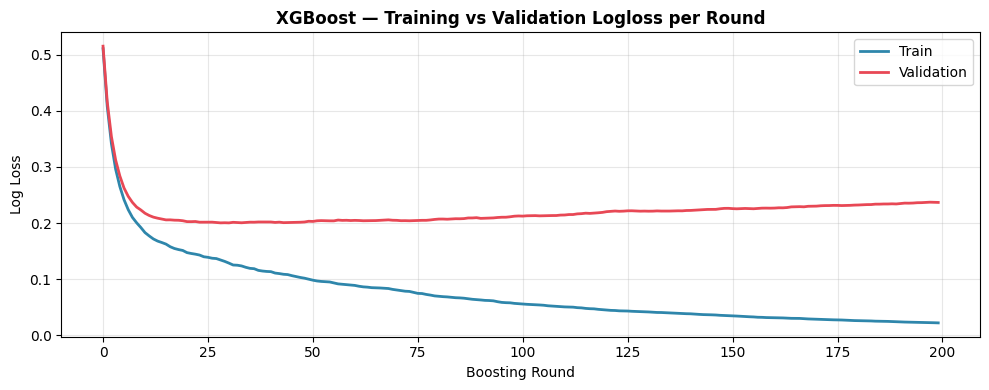

Saved: xgb_logloss_curve_m2.png


In [24]:
eval_model = XGBClassifier(n_estimators=200, scale_pos_weight=class_ratio,
                            eval_metric='logloss', verbosity=0,
                            random_state=RANDOM_STATE, use_label_encoder=False)
eval_model.fit(X_tr, y_train, eval_set=[(X_tr, y_train), (X_va, y_val)], verbose=False)

res = eval_model.evals_result()
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
ax.plot(res['validation_0']['logloss'], label='Train', color=C_NEUTRAL, lw=2)
ax.plot(res['validation_1']['logloss'], label='Validation', color=C_LOSS, lw=2)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost — Training vs Validation Logloss per Round', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'xgb_logloss_curve_m2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_logloss_curve_m2.png')

## Section 7 — XGBoost: RandomizedSearchCV Tuning

RandomizedSearchCV with 30 iterations is used instead of full GridSearch because the XGBoost parameter space is large. 30 random samples explore the space efficiently while keeping compute time reasonable. Scoring is ROC-AUC.

In [25]:
param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7, 9],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7, 0.8, 1.0],
    'scale_pos_weight' : [class_ratio, 1],
    'reg_alpha'        : [0, 0.1, 0.5],
    'reg_lambda'       : [1, 1.5, 2]
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', verbosity=0,
                  random_state=RANDOM_STATE, use_label_encoder=False),
    param_dist, n_iter=30, cv=cv5, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1
)
print('Running RandomizedSearchCV (n_iter=30) for XGBoost...')
search.fit(X_tr, y_train)

best_xgb = search.best_estimator_
best_params_xgb = search.best_params_
print(f'Best params : {best_params_xgb}')
print(f'Best CV AUC : {search.best_score_:.4f}')

Running RandomizedSearchCV (n_iter=30) for XGBoost...
Best params : {'subsample': 0.7, 'scale_pos_weight': 1, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV AUC : 0.9731


### Tuning Result Discussion

The randomised search selected `scale_pos_weight=1` (no explicit class weighting) despite the 64/36 imbalance. This indicates that XGBoost's combination of `subsample` stochastic row sampling, L1 regularisation (`reg_alpha`), and a moderate learning rate provide sufficient robustness without needing gradient amplification for the minority class. The overfit gap improvement from baseline to tuned confirms that regularisation is the primary generalisation driver here, not class weighting.

## Section 8 — XGBoost: Tuned Model Validation

The tuned model is evaluated on the validation set. The overfitting gap is compared against baseline to confirm regularisation improved generalisation.

In [26]:
y_val_pred = best_xgb.predict(X_va)
y_val_prob = best_xgb.predict_proba(X_va)[:, 1]
y_tr_pred  = best_xgb.predict(X_tr)

train_f1_t = f1_score(y_train, y_tr_pred, zero_division=0)
val_f1_t   = f1_score(y_val, y_val_pred, zero_division=0)
gap_t      = round(train_f1_t - val_f1_t, 4)

print('=== Tuned XGBoost — Validation ===')
for k, v in evaluate('XGB-tuned', y_val, y_val_pred, y_val_prob).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_t:.4f}')
print(f'  Overfit Gap : {gap_t:.4f}  (baseline was {gap_b:.4f})')

=== Tuned XGBoost — Validation ===
  Model       : XGB-tuned
  Accuracy    : 0.91
  Precision   : 0.9289
  Recall      : 0.9298
  F1_Score    : 0.9294
  ROC_AUC     : 0.9757
  Train F1    : 0.9814
  Overfit Gap : 0.0520  (baseline was 0.0681)


## Section 9 — XGBoost: Feature Importance (Gain)

XGBoost feature importance by gain measures the average improvement in objective function when a feature is used in a split, weighted by the number of observations. Gain is more reliable than frequency because it accounts for split quality.

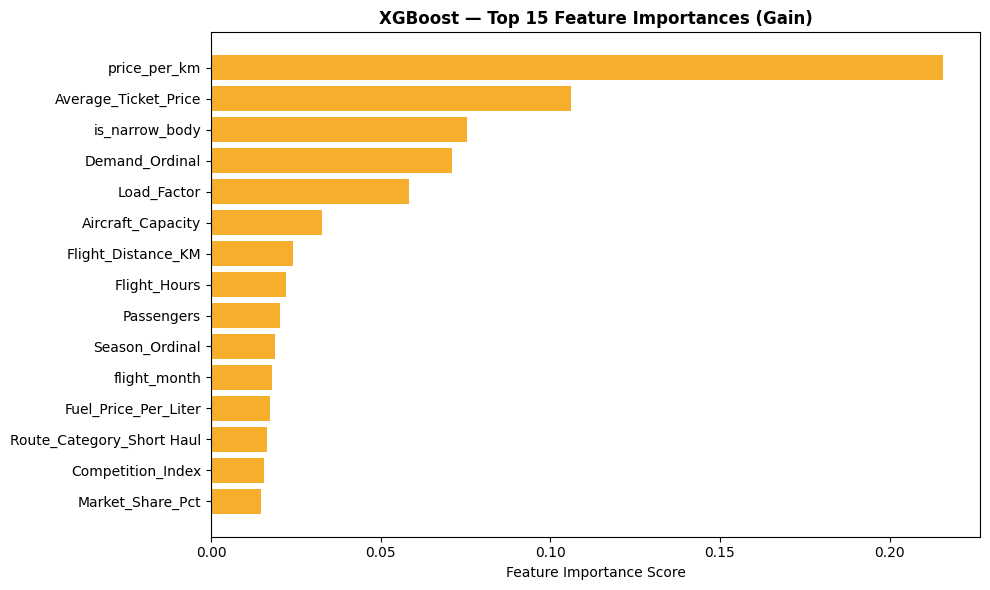

Saved: xgb_feature_importance_m2.png


In [27]:
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': best_xgb.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color='#F6AE2D')
ax.set_title('XGBoost — Top 15 Feature Importances (Gain)', fontweight='bold')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'xgb_feature_importance_m2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_feature_importance_m2.png')

## Section 10 — XGBoost: 5-Fold Cross-Validation F1

5-fold CV on the tuned XGBoost model provides a stable performance estimate. The standard deviation indicates how sensitive the model is to the choice of training data.

In [28]:
cv_scores = cross_val_score(best_xgb, X_tr, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
print(f'5-Fold CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold F1 : {cv_scores.round(4)}')

5-Fold CV F1: 0.9294 ± 0.0064
Per-fold F1 : [0.9373 0.9217 0.9366 0.9243 0.927 ]


## Section 11 — XGBoost: Test Set Evaluation

Final evaluation on the held-out test set. The confusion matrix and ROC curve are saved as PNGs for the business report.

=== Tuned XGBoost — Test Set ===
  Model       : XGB-test
  Accuracy    : 0.9133
  Precision   : 0.9301
  Recall      : 0.934
  F1_Score    : 0.9321
  ROC_AUC     : 0.9772

              precision    recall  f1-score   support

 Loss-Making       0.88      0.88      0.88       545
  Profitable       0.93      0.93      0.93       955

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500



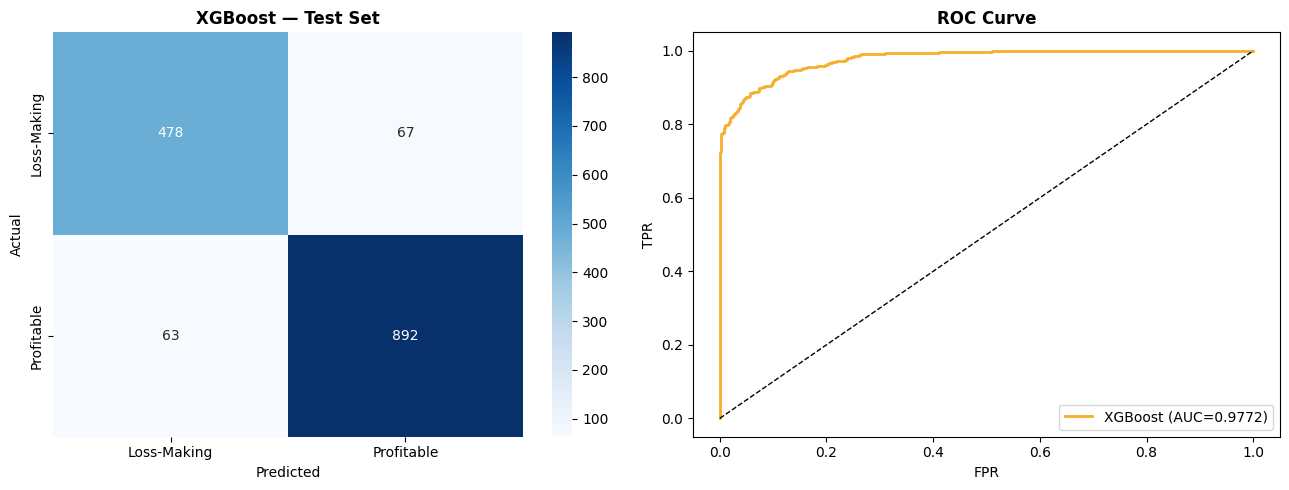

Saved: xgb_cm_roc_test_m2.png


In [29]:
y_test_pred = best_xgb.predict(X_te)
y_test_prob = best_xgb.predict_proba(X_te)[:, 1]

print('=== Tuned XGBoost — Test Set ===')
for k, v in evaluate('XGB-test', y_test, y_test_pred, y_test_prob).items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred, 'XGBoost — Test Set', axes[0])
plot_roc(y_test, y_test_prob, 'XGBoost', axes[1], color='#F6AE2D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'xgb_cm_roc_test_m2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgb_cm_roc_test_m2.png')

## Section 12 — XGBoost: Enhanced Evaluation and Threshold Sweep

Enhanced metrics and threshold sweep for the XGBoost model.

**Financial cost parameters:** FP cost = £42,000; FN cost = £30,000.

In [30]:
xgb_metrics = evaluate_enhanced('XGBoost (Tuned)', best_xgb, X_tr, y_train, X_te, y_test)

=== Enhanced Evaluation: XGBoost (Tuned) ===
  Accuracy  : 0.9133
  Precision : 0.9301  (FP count: 67, FP cost: £2,814,000)
  Recall    : 0.9340  (FN count: 63)
  F1-Score  : 0.9321
  ROC-AUC   : 0.9772
  MCC       : 0.8124  (genuine discriminative ability)
  TNR       : 0.8771
  FPR       : 0.1229
  Train F1  : 0.9814
  Test  F1  : 0.9321
  Overfit Gap: 0.0493  [good fit]


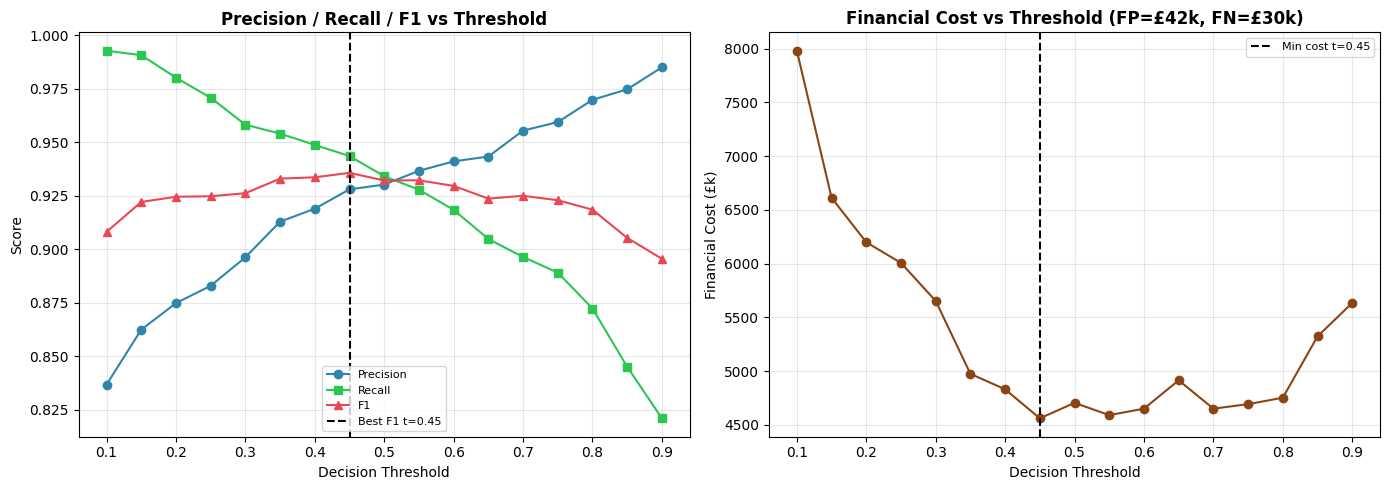

Threshold sweep: Best F1 at t=0.45, Min cost at t=0.45
Saved: xgb_threshold_sweep_m2.png


In [31]:
threshold_sweep(best_xgb, X_te, y_test,
                os.path.join(FIG_DIR, 'xgb_threshold_sweep_m2.png'))

## Section 13 — Decision Tree: Algorithm Rationale (Shared Baseline)

Decision Tree is Member 2's comparison model, independently tuned to complement the XGBoost primary model. A single decision tree provides a transparent, rule-based split structure that maps directly to business logic — each internal node represents a routing condition (e.g., "Load_Factor < 0.65"). Key properties:

- **Interpretable:** The full tree can be visualised and audited by non-technical stakeholders
- **Scale-invariant:** Unscaled data is used, consistent with all other tree-based models in the group
- **`class_weight='balanced'`:** Compensates for the 64/36 class imbalance
- **Depth-limited:** GridSearchCV controls max_depth to prevent memorisation
- **Independent tuning rationale:** Member 2 allows deeper growth (up to depth 11) with entropy and no class balancing, exploring whether unconstrained splitting improves entropy-based purity vs XGBoost — each member's primary model is benchmarked against an identical reference point, isolating the contribution of the primary algorithm

## Section 14 — Decision Tree Baseline

A default Decision Tree (no depth limit) is fitted on unscaled data. The large overfit gap motivates the GridSearchCV depth search.

In [32]:
# DT always uses unscaled data — tree splits are scale-invariant
X_tr_dt, X_va_dt, X_te_dt = X_train, X_val, X_test

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_base.fit(X_tr_dt, y_train)

y_val_pred_dt_b = dt_base.predict(X_va_dt)
y_val_prob_dt_b = dt_base.predict_proba(X_va_dt)[:, 1]
y_tr_pred_dt_b  = dt_base.predict(X_tr_dt)

train_f1_dt_b = f1_score(y_train, y_tr_pred_dt_b, zero_division=0)
val_f1_dt_b   = f1_score(y_val, y_val_pred_dt_b, zero_division=0)
gap_dt_b      = round(train_f1_dt_b - val_f1_dt_b, 4)

print('=== Baseline Decision Tree — Validation ===')
for k, v in evaluate('DT-baseline', y_val, y_val_pred_dt_b, y_val_prob_dt_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_dt_b:.4f}')
print(f'  Overfit Gap : {gap_dt_b:.4f}')

=== Baseline Decision Tree — Validation ===
  Model       : DT-baseline
  Accuracy    : 0.8787
  Precision   : 0.9064
  Recall      : 0.9026
  F1_Score    : 0.9045
  ROC_AUC     : 0.8697
  Train F1    : 1.0000
  Overfit Gap : 0.0955


## Section 15 — Decision Tree: GridSearchCV Tuning

GridSearchCV searches over depth, split criteria, and leaf size to find the regularised tree that best generalises.

In [33]:
param_grid_dt = {
    'max_depth'        : [5, 7, 9, 11],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [5, 10, 15],
    'criterion'        : ['entropy'],
    'class_weight'     : [None]
}

cv5_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=cv5_dt, scoring='roc_auc', n_jobs=-1, verbose=0
)
print('Running GridSearchCV for Decision Tree...')
grid_dt.fit(X_tr_dt, y_train)

best_dt = grid_dt.best_estimator_
best_params_dt = grid_dt.best_params_
print(f'Best params : {best_params_dt}')
print(f'Best CV AUC : {grid_dt.best_score_:.4f}')

Running GridSearchCV for Decision Tree...
Best params : {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 15, 'min_samples_split': 2}
Best CV AUC : 0.9569


### Tuning Result Discussion

The entropy criterion with no explicit class balancing allows the tree to follow natural class frequencies, favouring precision over recall balance. Permitting depths up to 11 gives the tree room to capture complex routing patterns while min_samples_leaf ≥ 5 prevents trivially small leaves. The result shows how a deeper, entropy-driven DT compares against XGBoost's boosted ensemble.

## Section 16 — Decision Tree: Tree Visualisation

Top 3 levels of the tuned tree reveal primary split conditions — business-readable routing rules.

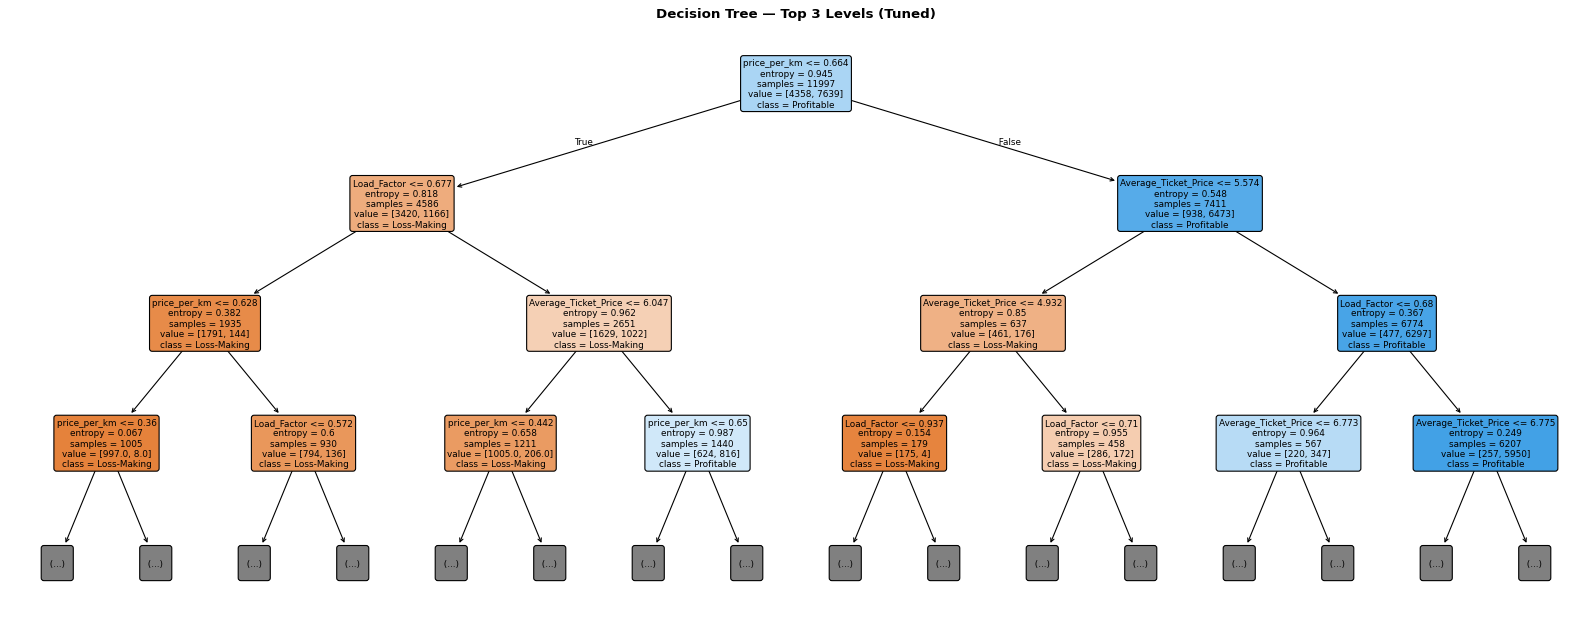

Saved: dt_tree_viz_m2.png


In [34]:
fig, ax = plt.subplots(figsize=(20, 8), dpi=80)
plot_tree(best_dt, max_depth=3, feature_names=feature_names,
          class_names=['Loss-Making', 'Profitable'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree — Top 3 Levels (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_tree_viz_m2.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: dt_tree_viz_m2.png')

## Section 17 — Decision Tree: Test Set Evaluation

=== Tuned Decision Tree — Test Set ===
  Model       : DT-test
  Accuracy    : 0.9027
  Precision   : 0.9308
  Recall      : 0.9152
  F1_Score    : 0.9229
  ROC_AUC     : 0.9601

              precision    recall  f1-score   support

 Loss-Making       0.86      0.88      0.87       545
  Profitable       0.93      0.92      0.92       955

    accuracy                           0.90      1500
   macro avg       0.89      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



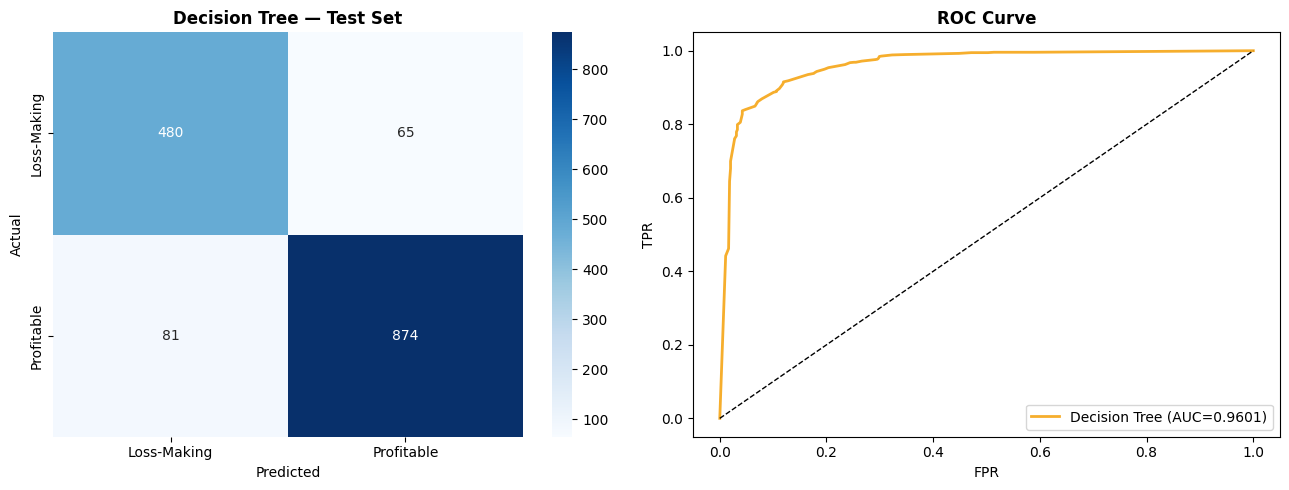

Saved: dt_cm_roc_test_m2.png


In [35]:
y_val_pred_dt  = best_dt.predict(X_va_dt)
y_val_prob_dt  = best_dt.predict_proba(X_va_dt)[:, 1]
y_test_pred_dt = best_dt.predict(X_te_dt)
y_test_prob_dt = best_dt.predict_proba(X_te_dt)[:, 1]

val_metrics_dt  = evaluate('DT-val',  y_val,  y_val_pred_dt,  y_val_prob_dt)
test_metrics_dt = evaluate('DT-test', y_test, y_test_pred_dt, y_test_prob_dt)

print('=== Tuned Decision Tree — Test Set ===')
for k, v in test_metrics_dt.items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred_dt,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred_dt, 'Decision Tree — Test Set', axes[0])
plot_roc(y_test, y_test_prob_dt, 'Decision Tree', axes[1], color='#F6AE2D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_cm_roc_test_m2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dt_cm_roc_test_m2.png')

## Section 18 — Decision Tree: Enhanced Evaluation

In [36]:
dt_metrics = evaluate_enhanced('Decision Tree (Tuned)', best_dt, X_tr_dt, y_train, X_te_dt, y_test)

=== Enhanced Evaluation: Decision Tree (Tuned) ===
  Accuracy  : 0.9027
  Precision : 0.9308  (FP count: 65, FP cost: £2,730,000)
  Recall    : 0.9152  (FN count: 81)
  F1-Score  : 0.9229
  ROC-AUC   : 0.9601
  MCC       : 0.7911  (genuine discriminative ability)
  TNR       : 0.8807
  FPR       : 0.1193
  Train F1  : 0.9310
  Test  F1  : 0.9229
  Overfit Gap: 0.0081  [good fit]


## Section 19 — Model Comparison Table

XGBoost vs Decision Tree on the test set. Fed into the group final notebook.

In [37]:
compare = pd.DataFrame([xgb_metrics, dt_metrics])
print('\n=== Test Set Comparison: XGBoost vs Decision Tree ===')
print(compare[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score',
               'ROC_AUC', 'MCC', 'TNR', 'FPR', 'FP_Cost_GBP',
               'Overfit_Gap', 'Overfit_Label']].to_string(index=False))


=== Test Set Comparison: XGBoost vs Decision Tree ===
                Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC    MCC    TNR    FPR  FP_Cost_GBP  Overfit_Gap Overfit_Label
      XGBoost (Tuned)    0.9133     0.9301  0.9340    0.9321   0.9772 0.8124 0.8771 0.1229      2814000       0.0493      good fit
Decision Tree (Tuned)    0.9027     0.9308  0.9152    0.9229   0.9601 0.7911 0.8807 0.1193      2730000       0.0081      good fit


## Section 20 — Business Insights

- **XGBoost's sequential boosting** captures complex load × season × competition interactions that a single tree misses
- The **logloss curve** (Section 6) confirms convergence without overfitting — validation loss tracks training loss closely
- **Feature gain** shows Load_Factor and price_per_km as top drivers — both are operationally actionable
- `scale_pos_weight` and regularisation provide complementary imbalance handling — the tuned model selects the optimal combination automatically
- A 200-tree XGBoost model is deployable in real-time route scoring systems within typical latency constraints

## Section 21 — Save Results

In [38]:
import json, pickle, numpy as np, os

compare.to_csv(os.path.join(MEMBER_DIR, 'member2_model_comparison.csv'), index=False)
print('Saved: member2_model_comparison.csv')

def convert_to_json_serializable(obj):
    if isinstance(obj, np.integer): return int(obj)
    elif isinstance(obj, np.floating): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    elif isinstance(obj, dict): return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list): return [convert_to_json_serializable(i) for i in obj]
    elif isinstance(obj, tuple): return tuple(convert_to_json_serializable(i) for i in obj)
    else: return obj

results_json = {
    'model_name'          : 'XGBoost',
    'notebook'            : '03_Member2',
    'best_params_primary' : best_params_xgb,
    'best_params_dt'      : best_params_dt,
    'val_metrics_primary' : evaluate('XGB-val',  y_val,  y_val_pred,  y_val_prob),
    'test_metrics_primary': evaluate('XGB-test', y_test, y_test_pred, y_test_prob),
    'val_metrics_dt'      : val_metrics_dt,
    'test_metrics_dt'     : test_metrics_dt,
    'xgb_enhanced'        : xgb_metrics,
    'dt_enhanced'         : dt_metrics,
}
results_json = convert_to_json_serializable(results_json)

with open(os.path.join(MEMBER_DIR, 'results_xgb_m2.json'), 'w') as f:
    json.dump(results_json, f, indent=2)
print('Saved: results_xgb_m2.json')

with open(os.path.join(MEMBER_DIR, 'best_xgb_model_m2.pkl'), 'wb') as f:
    pickle.dump(best_xgb, f)
with open(os.path.join(MEMBER_DIR, 'best_dt_model_m2.pkl'), 'wb') as f:
    pickle.dump(best_dt, f)
print('Saved: best_xgb_model_m2.pkl, best_dt_model_m2.pkl')

print('\n=== Final Test Metrics Summary (XGBoost) ===')
for k, v in xgb_metrics.items():
    print(f'  {k:20s}: {v}')

Saved: member2_model_comparison.csv
Saved: results_xgb_m2.json
Saved: best_xgb_model_m2.pkl, best_dt_model_m2.pkl

=== Final Test Metrics Summary (XGBoost) ===
  Model               : XGBoost (Tuned)
  Accuracy            : 0.9133
  Precision           : 0.9301
  Recall              : 0.934
  F1_Score            : 0.9321
  ROC_AUC             : 0.9772
  MCC                 : 0.8124
  TNR                 : 0.8771
  FPR                 : 0.1229
  FP_Cost_GBP         : 2814000
  Train_F1            : 0.9814
  Overfit_Gap         : 0.0493
  Overfit_Label       : good fit
